# Arithmetic Workflow

This notebook defines and reloads the arithmetic workflow with [`pyironflow`](https://github.com/pyiron/pyironflow) .

## Reload workflow in pyironflow

In [1]:
workflow_json_filename = "workflow.json"

In [2]:
from python_workflow_definition.pyiron_workflow import load_workflow_json

In [3]:
from pyironflow import PyironFlow

In [4]:
wf = load_workflow_json(file_name=workflow_json_filename)
PyironFlow([wf]).gui

![screenshot](screenshot.png)

In [5]:
wf.run()

{'get_square__get_square': 6.25}

## Define workflow in pyironflow

`to_function_node` wraps a plain Python function into a `pyiron_workflow` node that can be added to a `Workflow` graph. Nodes are assembled into a graph with attribute access: assigning `wf.<name> = node(...)` both registers the node under that name and connects its inputs to the outputs of other nodes already on the graph.

In [6]:
from python_workflow_definition.pyiron_workflow import write_workflow_json

In [7]:
from pyiron_workflow import Workflow, to_function_node

In [8]:
from workflow import (
    get_prod_and_div as _get_prod_and_div, 
    get_sum as _get_sum,
    get_square as _get_square,
)

In [9]:
get_prod_and_div = to_function_node("get_prod_and_div", _get_prod_and_div, "get_prod_and_div")
get_sum = to_function_node("get_sum", _get_sum, "get_sum")
get_square = to_function_node("get_square", _get_square, "get_square")

In [10]:
wf = Workflow("my_workflow")

In [11]:
wf.x = 1
wf.y = 2
wf.prod_and_div = get_prod_and_div(x=wf.x, y=wf.y)
wf.tmp_sum = get_sum(x=wf.prod_and_div["prod"], y=wf.prod_and_div["div"])
wf.square_result = get_square(x=wf.tmp_sum)

`wf.draw()` renders the resulting node graph, and `write_workflow_json` serializes `wf.graph_as_dict` into the PWD `workflow.json` format.

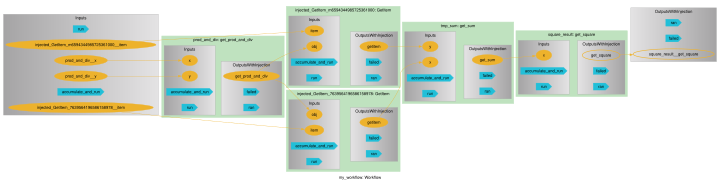

In [12]:
wf.draw(size=(10,10))

In [13]:
write_workflow_json(graph_as_dict=wf.graph_as_dict, file_name=workflow_json_filename)

In [14]:
!cat workflow.json

{
  "version": "0.1.0",
  "nodes": [
    {
      "id": 0,
      "type": "function",
      "value": "workflow.get_prod_and_div"
    },
    {
      "id": 1,
      "type": "function",
      "value": "workflow.get_sum"
    },
    {
      "id": 2,
      "type": "function",
      "value": "workflow.get_square"
    },
    {
      "id": 3,
      "type": "input",
      "name": "x",
      "value": 1
    },
    {
      "id": 4,
      "type": "input",
      "name": "y",
      "value": 2
    },
    {
      "id": 5,
      "type": "output",
      "name": "result"
    }
  ],
  "edges": [
    {
      "target": 1,
      "targetPort": "y",
      "source": 0,
      "sourcePort": "div"
    },
    {
      "target": 1,
      "targetPort": "x",
      "source": 0,
      "sourcePort": "prod"
    },
    {
      "target": 2,
      "targetPort": "x",
      "source": 1,
      "sourcePort": null
    },
    {
      "target": 0,
      "targetPort": "x",
      "source": 3,
      "sourcePort": null
    },
    {
      "t